# Explainable Artificial Intelligence for Financial Fraud Detection and Risk Scoring
**MSc Data Analytics — De Montfort University, Leicester**  
Muhammad Fahad Farooq (P2902499) | Supervisor: Taha Raseem

---
**How to run:** Place `creditcard.csv` in the same folder as this notebook, then run all cells top to bottom (`Kernel → Restart & Run All`).


## Section 1 — Environment Setup & Imports

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap xgboost lime scipy --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    matthews_corrcoef
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# XGBoost
from xgboost import XGBClassifier

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# XAI
import shap
from lime.lime_tabular import LimeTabularExplainer

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 2 — Data Loading & Exploratory Data Analysis

The Credit Card Fraud Detection dataset contains 284,807 transactions from European cardholders (September 2013).  
Features V1–V28 are PCA-transformed for privacy. `Amount` and `Time` are original scale.  
`Class` = 1 (fraud), 0 (legitimate).


In [3]:
# ── Load dataset ──────────────────────────────────────────────────────────
df = pd.read_csv("creditcard.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# ── Basic info & quality checks ──────────────────────────────────────────
print("=" * 55)
print("DATASET INFORMATION")
print("=" * 55)
df.info()
print(f"\nMissing values total: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicates. Rows remaining: {len(df):,}")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

In [6]:
# ── Class imbalance analysis ──────────────────────────────────────────────
fraud  = df[df['Class'] == 1]
normal = df[df['Class'] == 0]
fraud_pct = len(fraud) / len(df) * 100

print(f"Legitimate transactions : {len(normal):,}  ({100 - fraud_pct:.4f}%)")
print(f"Fraud transactions      : {len(fraud):,}  ({fraud_pct:.4f}%)")
print(f"Imbalance ratio         : {len(normal) // len(fraud)}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
bars = axes[0].bar(['Legitimate', 'Fraudulent'],
                   [len(normal), len(fraud)],
                   color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [len(normal), len(fraud)]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.005, f'{val:,}', ha='center', fontsize=10)
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie([len(normal), len(fraud)],
            labels=[f'Legitimate
({100-fraud_pct:.2f}%)',
                    f'Fraudulent
({fraud_pct:.4f}%)'],
            colors=['#2196F3', '#F44336'],
            startangle=90, explode=(0, 0.1),
            autopct='%1.3f%%', textprops={'fontsize': 10})
axes[1].set_title('Class Distribution', fontweight='bold')

plt.suptitle('Class Imbalance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

SyntaxError: unterminated f-string literal (detected at line 24) (1699787463.py, line 24)

NameError: name 'normal' is not defined

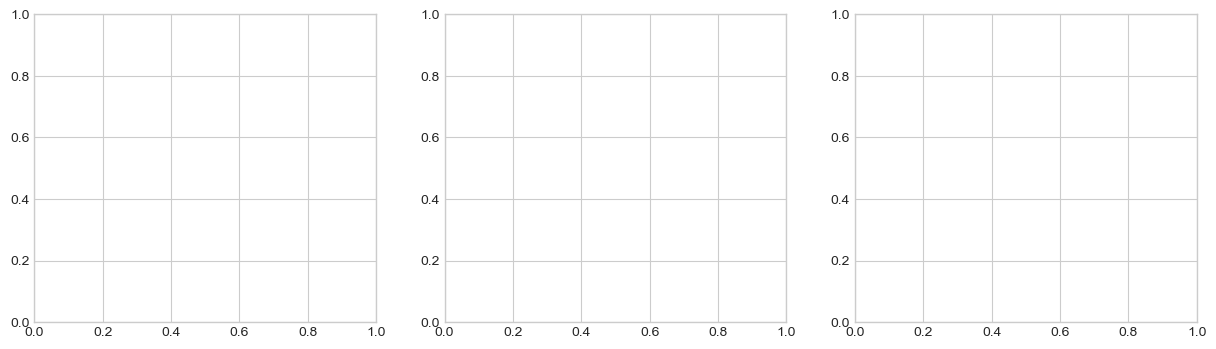

In [7]:
# ── Transaction amount analysis ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram (log-scaled y)
axes[0].hist(normal['Amount'], bins=80, alpha=0.5, color='#2196F3',
             label='Legitimate', density=True)
axes[0].hist(fraud['Amount'],  bins=80, alpha=0.7, color='#F44336',
             label='Fraudulent', density=True)
axes[0].set_yscale('log')
axes[0].set_xlabel('Amount (€)')
axes[0].set_title('Amount Distribution (log y)', fontweight='bold')
axes[0].legend()

# Box plot
axes[1].boxplot([normal['Amount'], fraud['Amount']],
                labels=['Legitimate', 'Fraudulent'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Amount by Class', fontweight='bold')
axes[1].set_ylabel('Amount (€)')

# Stats table
stats_df = pd.DataFrame({
    'Legitimate': normal['Amount'].describe(),
    'Fraudulent': fraud['Amount'].describe()
}).round(2)
axes[2].axis('off')
tbl = axes[2].table(cellText=stats_df.values,
                    rowLabels=stats_df.index,
                    colLabels=stats_df.columns,
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.4)
axes[2].set_title('Descriptive Statistics', fontweight='bold')

plt.suptitle('Transaction Amount Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Temporal pattern: hour of day ─────────────────────────────────────────
# Convert raw 'Time' (seconds) → hour of day
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

fraud_by_hour  = df[df['Class'] == 1]['Hour'].value_counts().sort_index()
normal_by_hour = df[df['Class'] == 0]['Hour'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, color, label in [
    (axes[0], normal_by_hour, '#2196F3', 'Legitimate'),
    (axes[1], fraud_by_hour,  '#F44336', 'Fraudulent')
]:
    ax.fill_between(data.index, data.values, alpha=0.4, color=color)
    ax.plot(data.index, data.values, color=color, linewidth=2)
    ax.set_title(f'{label} Transactions by Hour of Day', fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Count')

plt.suptitle('Temporal Transaction Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("Fraud transactions show distinct hourly patterns vs legitimate ones.")
print("This suggests time-of-day is an implicit signal even in PCA-transformed data.")

In [ ]:
# ── Feature correlation heatmap ───────────────────────────────────────────
plt.figure(figsize=(16, 12))
corr = df.drop(columns=['Hour']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, linewidths=0.2, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlated features with Class
class_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False)
print("Top 10 features most correlated with Class (absolute value):")
print(class_corr.head(10).to_string())

In [ ]:
# ── Statistical significance: Mann-Whitney U test ─────────────────────────
feature_cols = [c for c in df.columns if c not in ['Class', 'Hour', 'Time']]
results = []
for col in feature_cols:
    stat, p = stats.mannwhitneyu(
        df[df['Class'] == 1][col],
        df[df['Class'] == 0][col],
        alternative='two-sided'
    )
    results.append({'Feature': col, 'U-Statistic': round(stat), 'p-value': round(p, 6),
                    'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'})

results_df = pd.DataFrame(results).sort_values('p-value')
print("Mann-Whitney U test: Fraud vs Legitimate (top 15 most significant features)")
print("=" * 70)
print(results_df.head(15).to_string(index=False))
print(f"\nFeatures with p < 0.05: {(results_df['p-value'] < 0.05).sum()} / {len(results_df)}")

## Section 3 — Feature Engineering, Preprocessing & SMOTE

Key decisions:
- **Scale** `Amount` with `StandardScaler` (V1–V28 are already PCA-scaled)
- **Engineer** `Amount_log` (log1p transform handles zeros, reduces skewness)
- **Retain** `Hour` as temporal engineered feature
- **Isolation Forest** anomaly score as unsupervised signal
- **Drop** raw `Time` column
- **SMOTE** applied to training split only — prevents data leakage


In [8]:
# ── Feature engineering ───────────────────────────────────────────────────
df_feat = df.copy()

# Scale Amount
scaler_amount = StandardScaler()
df_feat['Amount_scaled'] = scaler_amount.fit_transform(df_feat[['Amount']])
df_feat['Amount_log']    = np.log1p(df_feat['Amount'])   # log-transform

# Drop original Amount and raw Time (keeping Hour)
df_feat = df_feat.drop(columns=['Amount', 'Time'])

print(f"Features after engineering: {df_feat.shape[1] - 1} (excluding Class)")
print(f"New features added: Amount_scaled, Amount_log, Hour")
df_feat.head(3)

Features after engineering: 30 (excluding Class)
New features added: Amount_scaled, Amount_log, Hour


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Amount_log
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244200,5.014760
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342584,1.305626
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.158900,5.939276


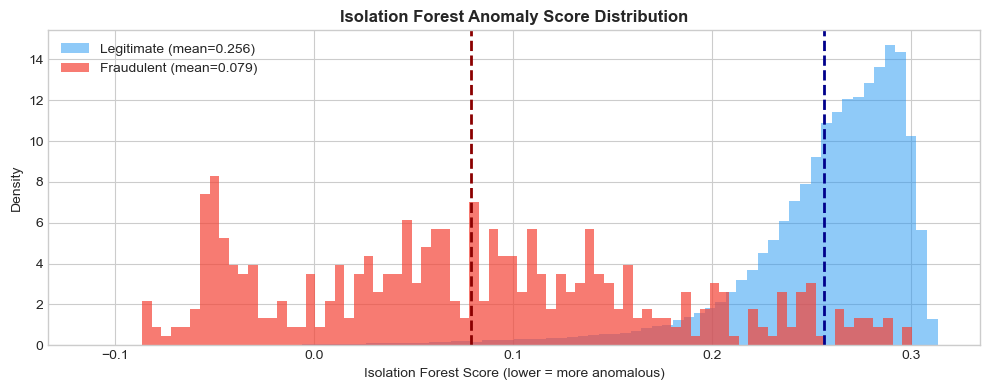

Mann-Whitney U (fraud < normal): U=7371754, p=2.73e-246
→ Isolation Forest scores SIGNIFICANTLY distinguish fraud


In [9]:
# ── Isolation Forest: unsupervised anomaly score ──────────────────────────
# Trained on ALL features (no Class label) to detect statistical outliers
X_all = df_feat.drop(columns=['Class'])
iso = IsolationForest(contamination=0.002, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_all)
df_feat['anomaly_score'] = iso.decision_function(X_all)  # lower = more anomalous

# Validate: do scores separate fraud from normal?
fraud_scores  = df_feat[df_feat['Class'] == 1]['anomaly_score']
normal_scores = df_feat[df_feat['Class'] == 0]['anomaly_score']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal_scores, bins=80, alpha=0.5, color='#2196F3',
        label=f'Legitimate (mean={normal_scores.mean():.3f})', density=True)
ax.hist(fraud_scores,  bins=80, alpha=0.7, color='#F44336',
        label=f'Fraudulent (mean={fraud_scores.mean():.3f})', density=True)
ax.axvline(fraud_scores.mean(),  color='darkred',  linestyle='--', linewidth=2)
ax.axvline(normal_scores.mean(), color='darkblue', linestyle='--', linewidth=2)
ax.set_xlabel('Isolation Forest Score (lower = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('Isolation Forest Anomaly Score Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

u_stat, p_val = stats.mannwhitneyu(fraud_scores, normal_scores, alternative='less')
print(f"Mann-Whitney U (fraud < normal): U={u_stat:.0f}, p={p_val:.2e}")
print("→ Isolation Forest scores SIGNIFICANTLY distinguish fraud" if p_val < 0.05 
      else "→ Not significant")

In [10]:
# ── Train / Test split then SMOTE ─────────────────────────────────────────
X = df_feat.drop(columns=['Class'])
y = df_feat['Class']

# Stratified split preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# SMOTE on training data ONLY (never on test — would cause data leakage)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Split & SMOTE Summary:")
print(f"  Training (before SMOTE) : {X_train.shape}  | Fraud={y_train.sum():,}  | Ratio={y_train.value_counts()[0]//y_train.value_counts()[1]}:1")
print(f"  Training (after  SMOTE) : {X_train_res.shape}  | Fraud={y_train_res.sum():,}  | Ratio=1:1")
print(f"  Test set (unchanged)    : {X_test.shape}  | Fraud={y_test.sum():,}")
print()
print("IMPORTANT: SMOTE is ONLY applied to training data.")
print("The test set retains the original distribution for realistic evaluation.")

Split & SMOTE Summary:
  Training (before SMOTE) : (226980, 31)  | Fraud=378  | Ratio=599:1
  Training (after  SMOTE) : (453204, 31)  | Fraud=226,602  | Ratio=1:1
  Test set (unchanged)    : (56746, 31)  | Fraud=95

IMPORTANT: SMOTE is ONLY applied to training data.
The test set retains the original distribution for realistic evaluation.


## Section 4 — Model Development & Training

Three algorithms are trained and compared:
- **Logistic Regression** — linear, interpretable baseline
- **Random Forest** — ensemble method, handles non-linearity
- **XGBoost** — gradient boosted trees, state-of-the-art for tabular fraud data

Each uses `class_weight='balanced'` or `scale_pos_weight` to further address imbalance.


In [11]:
# ── Helper function: train & evaluate any model ───────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, compute all key metrics, return dict + predictions."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    report = classification_report(y_te, y_pred, output_dict=True)
    return {
        'name'      : name,
        'Precision' : round(report['1']['precision'], 4),
        'Recall'    : round(report['1']['recall'],    4),
        'F1-Score'  : round(report['1']['f1-score'],  4),
        'ROC-AUC'   : round(roc_auc_score(y_te, y_prob), 4),
        'PR-AUC'    : round(average_precision_score(y_te, y_prob), 4),
        'MCC'       : round(matthews_corrcoef(y_te, y_pred), 4),
    }, y_pred, y_prob, model

print("evaluate_model() helper function defined.")

evaluate_model() helper function defined.


In [12]:
# ── Logistic Regression ───────────────────────────────────────────────────
lr_base = LogisticRegression(
    max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
)
lr_metrics, y_pred_lr, y_prob_lr, lr = evaluate_model(
    'Logistic Regression', lr_base, X_train_res, y_train_res, X_test, y_test
)
print("Logistic Regression — Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))

Logistic Regression — Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.86      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



In [13]:
# ── Random Forest ─────────────────────────────────────────────────────────
rf_base = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'
)
rf_metrics, y_pred_rf, y_prob_rf, rf = evaluate_model(
    'Random Forest', rf_base, X_train_res, y_train_res, X_test, y_test
)
print("Random Forest — Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))

Random Forest — Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.70      0.79      0.74        95

    accuracy                           1.00     56746
   macro avg       0.85      0.89      0.87     56746
weighted avg       1.00      1.00      1.00     56746



In [14]:
# ── XGBoost ───────────────────────────────────────────────────────────────
# scale_pos_weight = neg/pos ratio → tells XGBoost to weight fraud cases more
scale_pw = int(y_train.value_counts()[0] / y_train.value_counts()[1])
print(f"XGBoost scale_pos_weight = {scale_pw} (= ratio of normal:fraud in training set)")

xgb_base = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    eval_metric='aucpr',
    random_state=RANDOM_STATE, verbosity=0
)
xgb_metrics, y_pred_xgb, y_prob_xgb, xgb = evaluate_model(
    'XGBoost', xgb_base, X_train_res, y_train_res, X_test, y_test
)
print("\nXGBoost — Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))

XGBoost scale_pos_weight = 599 (= ratio of normal:fraud in training set)

XGBoost — Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56651
       Fraud       0.15      0.84      0.26        95

    accuracy                           0.99     56746
   macro avg       0.58      0.92      0.63     56746
weighted avg       1.00      0.99      0.99     56746



## Section 5 — Comprehensive Model Evaluation

**Why accuracy is misleading for fraud:** With 0.17% fraud, a model predicting "always legitimate" achieves 99.83% accuracy yet catches zero fraud. We use:
- **Recall** — what fraction of actual fraud is caught
- **Precision** — of flagged transactions, how many are real fraud
- **F1-Score** — harmonic mean of precision and recall
- **ROC-AUC** — area under ROC curve
- **PR-AUC** — area under Precision-Recall curve *(best metric for imbalanced data)*
- **MCC** — Matthews Correlation Coefficient *(gold standard for imbalance)*

**Cost model:** FN (missed fraud) ≈ €120 | FP (false alarm) ≈ €5


In [15]:
# ── Model comparison table ────────────────────────────────────────────────
metrics_list = [lr_metrics, rf_metrics, xgb_metrics]
comparison = pd.DataFrame(metrics_list).set_index('name')
comparison.index.name = 'Model'
print("Model Performance Comparison:")
print("=" * 70)
print(comparison.to_string())
print("\n* PR-AUC is the most informative metric for highly imbalanced fraud data.")
print("* MCC = Matthews Correlation Coefficient: accounts for all four confusion matrix cells.")

Model Performance Comparison:
                     Precision  Recall  F1-Score  ROC-AUC  PR-AUC     MCC
Model                                                                    
Logistic Regression     0.0516  0.8632    0.0974   0.9546  0.6803  0.2073
Random Forest           0.7009  0.7895    0.7426   0.9753  0.7945  0.7434
XGBoost                 0.1509  0.8421    0.2560   0.9548  0.7791  0.3545

* PR-AUC is the most informative metric for highly imbalanced fraud data.
* MCC = Matthews Correlation Coefficient: accounts for all four confusion matrix cells.


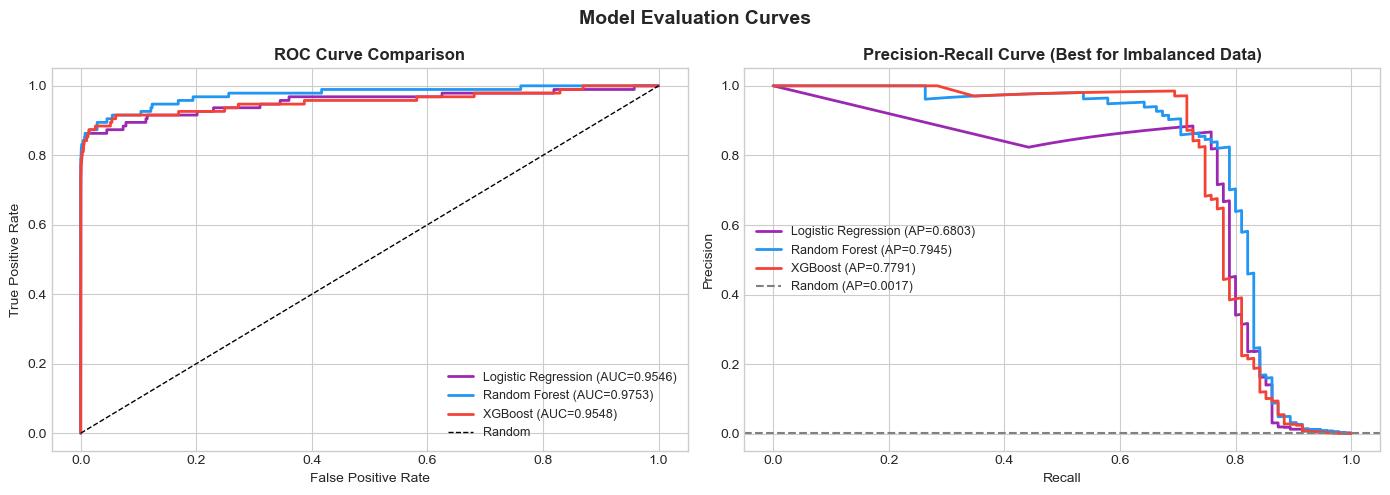

In [16]:
# ── ROC and Precision-Recall curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_styles = [
    ('Logistic Regression', y_prob_lr,  '#9C27B0'),
    ('Random Forest',        y_prob_rf,  '#2196F3'),
    ('XGBoost',              y_prob_xgb, '#F44336'),
]

# ROC curves
for name, probs, col in model_styles:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=col, linewidth=2, label=f'{name} (AUC={auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].legend(fontsize=9)

# Precision-Recall curves
for name, probs, col in model_styles:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, color=col, linewidth=2, label=f'{name} (AP={ap:.4f})')
baseline = y_test.sum() / len(y_test)
axes[1].axhline(y=baseline, color='gray', linestyle='--',
                label=f'Random (AP={baseline:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Best for Imbalanced Data)',
                   fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Model Evaluation Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

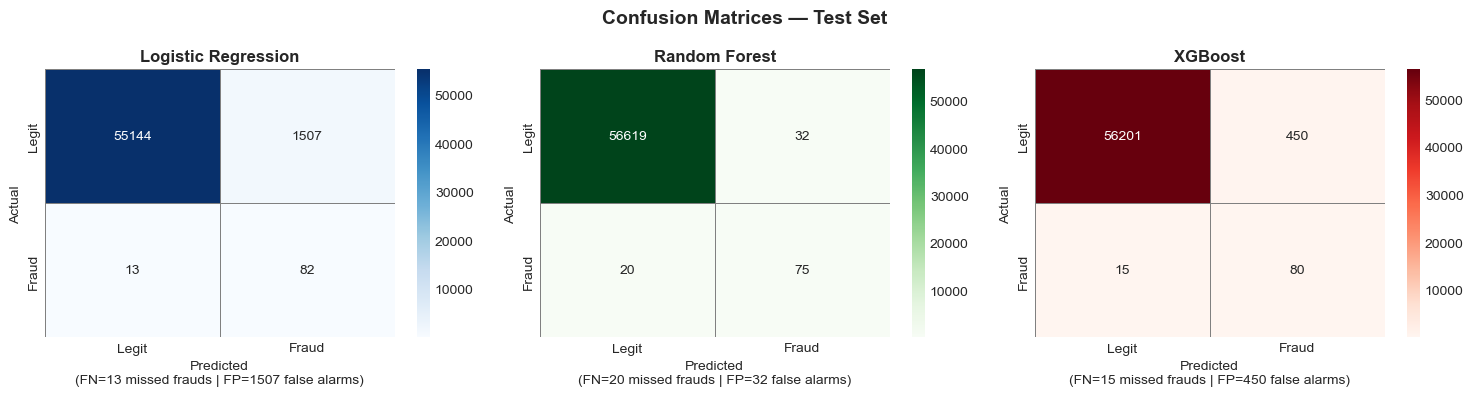

In [17]:
# ── Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred, cmap) in zip(axes, [
    ('Logistic Regression', y_pred_lr,  'Blues'),
    ('Random Forest',        y_pred_rf,  'Greens'),
    ('XGBoost',              y_pred_xgb, 'Reds'),
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'],
                linewidths=0.5, linecolor='gray')
    fn = cm[1][0]; fp = cm[0][1]
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel(f'Predicted\n(FN={fn} missed frauds | FP={fp} false alarms)')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Cost-sensitive financial analysis ─────────────────────────────────────
COST_FN = 120   # Cost of missing a fraud (€)
COST_FP = 5     # Cost of false alarm (€)

print(f"Cost Model: FN = €{COST_FN} (missed fraud) | FP = €{COST_FP} (false alarm)")
print("=" * 65)
for name, y_pred in [('Logistic Regression', y_pred_lr),
                      ('Random Forest',       y_pred_rf),
                      ('XGBoost',             y_pred_xgb)]:
    cm = confusion_matrix(y_test, y_pred)
    fn, fp = cm[1][0], cm[0][1]
    cost = fn * COST_FN + fp * COST_FP
    print(f"{name:<25} | FN={fn:4d} | FP={fp:5d} | Estimated Cost = €{cost:,.0f}")

Cost Model: FN = €120 (missed fraud) | FP = €5 (false alarm)
Logistic Regression       | FN=  13 | FP= 1507 | Estimated Cost = €9,095
Random Forest             | FN=  20 | FP=   32 | Estimated Cost = €2,560
XGBoost                   | FN=  15 | FP=  450 | Estimated Cost = €4,050


In [19]:
# ── 5-fold cross-validation (on original training data, no SMOTE) ─────────
print("Stratified 5-Fold Cross-Validation — ROC-AUC")
print("(CV on original training split without SMOTE to measure true generalisation)")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in [
    ('Logistic Regression',
     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                        class_weight='balanced')),
    ('Random Forest',
     RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                            n_jobs=-1, class_weight='balanced')),
    ('XGBoost',
     XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                   verbosity=0, eval_metric='auc',
                   scale_pos_weight=scale_pw)),
]:
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    print(f"{name:<25} ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

Stratified 5-Fold Cross-Validation — ROC-AUC
(CV on original training split without SMOTE to measure true generalisation)
Logistic Regression       ROC-AUC: 0.9813 ± 0.0091
Random Forest             ROC-AUC: 0.9445 ± 0.0202
XGBoost                   ROC-AUC: 0.9766 ± 0.0065


## Section 6 — Explainable AI: SHAP Analysis

**SHAP (SHapley Additive exPlanations)** provides theoretically grounded feature attributions based on cooperative game theory (Lundberg & Lee, 2017). Shapley values guarantee:
- **Efficiency** — sum of attributions equals prediction − baseline
- **Consistency** — if a feature contributes more in one model, it gets higher attribution
- **Null player** — features with zero contribution get SHAP = 0

We use XGBoost (best performer) with TreeExplainer (exact, polynomial-time for tree models).


In [20]:
# ── SHAP TreeExplainer setup ──────────────────────────────────────────────
shap.initjs()

# Sample 2000 test instances for speed (full X_test is ~57k rows)
sample_size = min(2000, len(X_test))
sample_idx  = np.random.choice(len(X_test), size=sample_size, replace=False)
X_test_sample = X_test.iloc[sample_idx].reset_index(drop=True)
y_test_sample = y_test.iloc[sample_idx].reset_index(drop=True)

# Create SHAP explainer (TreeExplainer is exact for XGBoost)
shap_explainer = shap.TreeExplainer(xgb)
shap_values    = shap_explainer.shap_values(X_test_sample)

print(f"SHAP values computed for {len(X_test_sample)} test samples.")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (baseline): {shap_explainer.expected_value:.4f}")

SHAP values computed for 2000 test samples.
SHAP values shape: (2000, 31)
Expected value (baseline): 8.3402


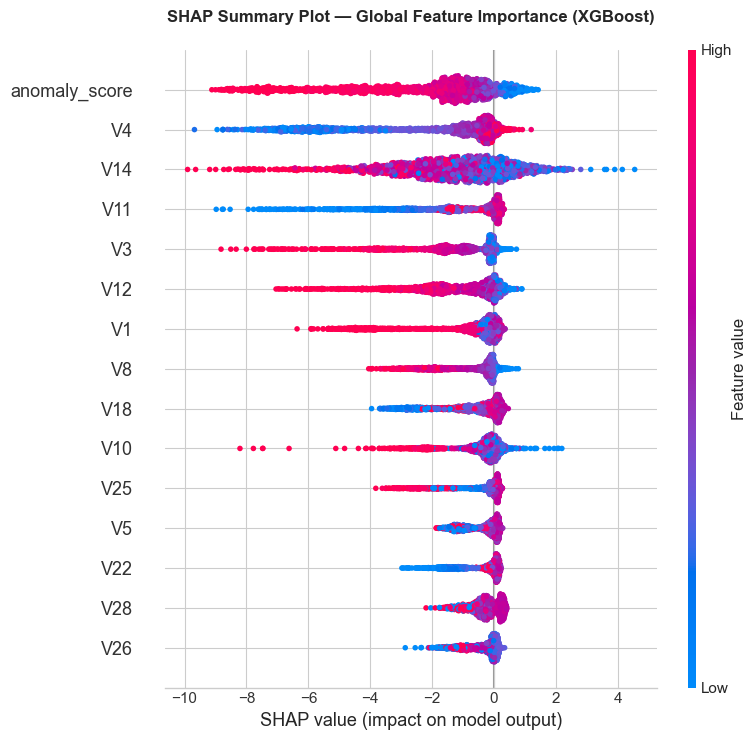

Interpretation:
  Each point = one transaction.
  Colour = feature value (red=high, blue=low).
  X-axis = SHAP value: positive pushes toward Fraud, negative toward Legitimate.


In [21]:
# ── SHAP global summary (beeswarm) ────────────────────────────────────────
shap.summary_plot(shap_values, X_test_sample, max_display=15,
                  show=False, plot_type='dot')
plt.title('SHAP Summary Plot — Global Feature Importance (XGBoost)',
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print("  Each point = one transaction.")
print("  Colour = feature value (red=high, blue=low).")
print("  X-axis = SHAP value: positive pushes toward Fraud, negative toward Legitimate.")

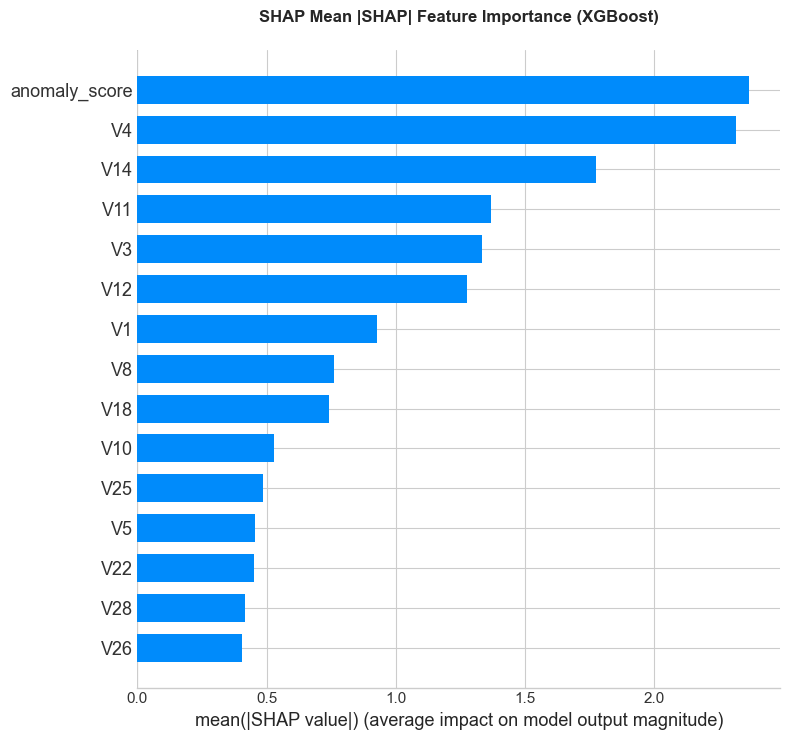

In [22]:
# ── SHAP global bar chart ─────────────────────────────────────────────────
shap.summary_plot(shap_values, X_test_sample, plot_type='bar',
                  max_display=15, show=False)
plt.title('SHAP Mean |SHAP| Feature Importance (XGBoost)',
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Select a correctly-predicted fraud transaction for local explanation ───
fraud_mask = (y_test_sample.values == 1)
fraud_in_sample = np.where(fraud_mask)[0]
print(f"Fraud cases in sample: {len(fraud_in_sample)}")

# Find one that was correctly predicted as fraud
correct_fraud = [i for i in fraud_in_sample
                 if xgb.predict(X_test_sample.iloc[[i]])[0] == 1]

if len(correct_fraud) == 0:
    local_idx = int(fraud_in_sample[0])
    print(f"No correctly-predicted fraud found; using fraud index {local_idx} anyway.")
else:
    local_idx = int(correct_fraud[0])

print(f"Using sample index {local_idx} for local (per-transaction) explanations.")
print(f"Actual class: {'FRAUD' if y_test_sample.iloc[local_idx] == 1 else 'LEGITIMATE'}")
print(f"Predicted probability of fraud: {xgb.predict_proba(X_test_sample.iloc[[local_idx]])[0,1]:.4f}")

Fraud cases in sample: 7
Using sample index 836 for local (per-transaction) explanations.
Actual class: FRAUD
Predicted probability of fraud: 1.0000


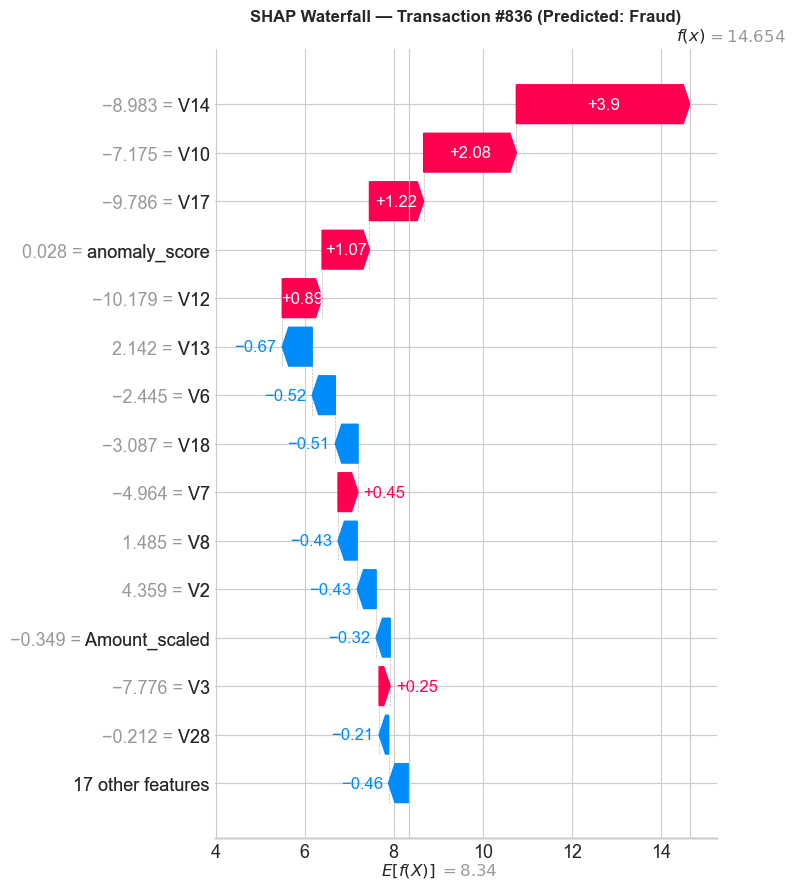


Waterfall interpretation:
  E[f(x)] = baseline (average model output across training data)
  f(x)    = this transaction's model output (log-odds)
  Red bars = features pushing prediction toward Fraud
  Blue bars = features pushing prediction toward Legitimate


In [24]:
# ── SHAP waterfall plot — single transaction ──────────────────────────────
shap_exp = shap.Explanation(
    values        = shap_values[local_idx],
    base_values   = shap_explainer.expected_value,
    data          = X_test_sample.iloc[local_idx],
    feature_names = list(X_test_sample.columns)
)

shap.plots.waterfall(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Transaction #{local_idx} (Predicted: Fraud)',
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nWaterfall interpretation:")
print("  E[f(x)] = baseline (average model output across training data)")
print("  f(x)    = this transaction's model output (log-odds)")
print("  Red bars = features pushing prediction toward Fraud")
print("  Blue bars = features pushing prediction toward Legitimate")

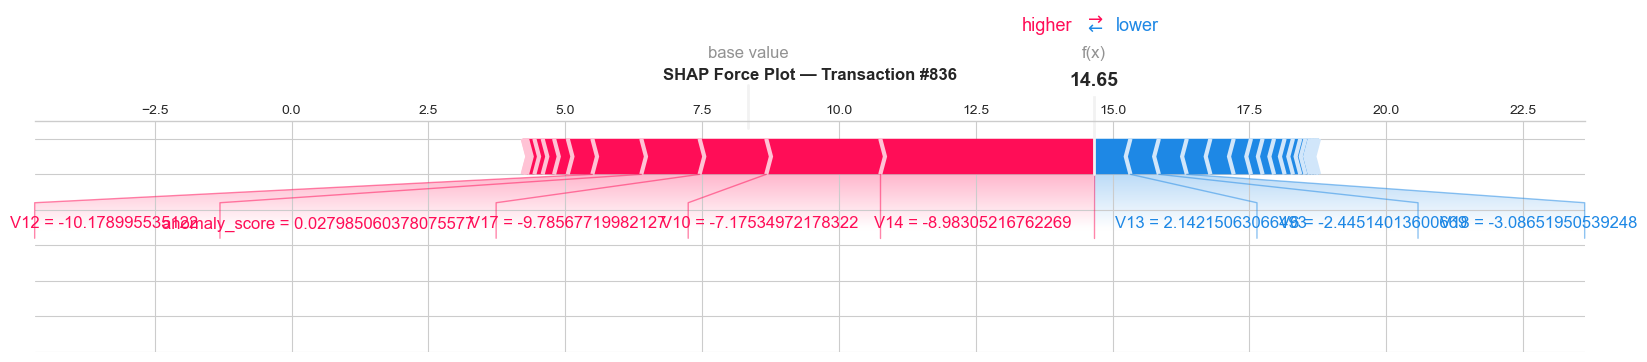

In [25]:
# ── SHAP force plot — single transaction ──────────────────────────────────
shap.force_plot(
    shap_explainer.expected_value,
    shap_values[local_idx],
    X_test_sample.iloc[local_idx],
    feature_names=list(X_test_sample.columns),
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — Transaction #{local_idx}', fontweight='bold', pad=30)
plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ── SHAP dependence plots — top 2 most important features ─────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top2_idx  = mean_abs_shap.argsort()[-2:][::-1]
top2_feats = [X_test_sample.columns[i] for i in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2_feats):
    shap.dependence_plot(feat, shap_values, X_test_sample, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.suptitle(
    'Feature Value vs SHAP Contribution
'
    '(Colour = strongest interacting feature)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

SyntaxError: unterminated string literal (detected at line 12) (2147071299.py, line 12)

## Section 7 — Explainable AI: LIME Analysis

**LIME (Local Interpretable Model-Agnostic Explanations)** builds a local linear surrogate model by perturbing the input and observing how predictions change (Ribeiro et al., 2016).

**Key differences from SHAP:**
| | SHAP | LIME |
|---|---|---|
| Scope | Global + Local | Local only |
| Model-specific? | TreeExplainer is XGBoost-specific | Model-agnostic |
| Theoretical grounding | Shapley values (game theory) | Local linear approximation |
| Stability | High | Can vary between runs |

Comparing LIME and SHAP for the **same transaction** tests consistency of explanations.


In [27]:
# ── LIME explainer setup ──────────────────────────────────────────────────
lime_explainer = LimeTabularExplainer(
    training_data         = X_train_res.values,
    feature_names         = list(X_train_res.columns),
    class_names           = ['Legitimate', 'Fraud'],
    mode                  = 'classification',
    random_state          = RANDOM_STATE,
    discretize_continuous = True
)
print("LIME explainer created successfully.")
print(f"Training data shape passed to LIME: {X_train_res.shape}")

LIME explainer created successfully.
Training data shape passed to LIME: (453204, 31)


In [28]:
# ── LIME explanation — same transaction as SHAP ───────────────────────────
lime_exp = lime_explainer.explain_instance(
    data_row   = X_test_sample.iloc[local_idx].values,
    predict_fn = xgb.predict_proba,
    num_features = 15,
    num_samples  = 5000
)

print(f"LIME explanation for transaction #{local_idx}")
print(f"LIME predicted probability of Fraud: {lime_exp.predict_proba[1]:.4f}")
print(f"XGBoost predicted probability of Fraud: "
      f"{xgb.predict_proba(X_test_sample.iloc[[local_idx]])[0,1]:.4f}")
print()
print("Top feature contributions from LIME (positive = toward Fraud):")
print("-" * 65)
for feat, weight in sorted(lime_exp.as_list(label=1), key=lambda x: abs(x[1]), reverse=True):
    bar = '█' * min(int(abs(weight) * 300), 30)
    sign = '+' if weight > 0 else '-'
    print(f"  {sign}{bar:<30} {feat[:45]:<45}  w={weight:+.4f}")

LIME explanation for transaction #836
LIME predicted probability of Fraud: 1.0000
XGBoost predicted probability of Fraud: 1.0000

Top feature contributions from LIME (positive = toward Fraud):
-----------------------------------------------------------------
  +██████████████████████████████ V14 <= -6.71                                   w=+0.1492
  +██████████████████████████████ anomaly_score <= 0.08                          w=+0.1394
  +██████████████████████████████ V12 <= -5.35                                   w=+0.1101
  +███████████████████████████    V4 > 4.00                                      w=+0.0913
  +█████████████████████          V10 <= -4.53                                   w=+0.0720
  -█████████████████              V8 > 0.85                                      w=-0.0578
  +███████████████                V3 <= -4.80                                    w=+0.0528
  +██████████████                 V11 > 3.53                                     w=+0.0492
  +█████████ 

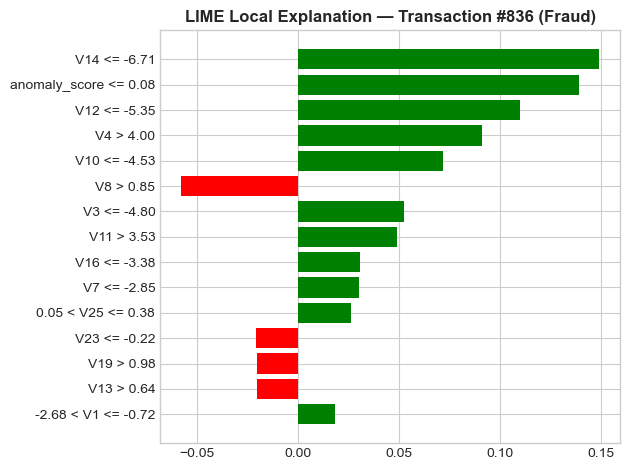

In [29]:
# ── LIME plot ─────────────────────────────────────────────────────────────
lime_fig = lime_exp.as_pyplot_figure(label=1)
plt.title(f'LIME Local Explanation — Transaction #{local_idx} (Fraud)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ── LIME vs SHAP agreement analysis ───────────────────────────────────────
print("=" * 65)
print(f"LIME vs SHAP Agreement Analysis — Transaction #{local_idx}")
print("=" * 65)

# SHAP top-10 feature names
shap_contrib    = dict(zip(X_test_sample.columns, shap_values[local_idx]))
shap_top10_names = set([
    f for f, _ in sorted(shap_contrib.items(),
                         key=lambda x: abs(x[1]), reverse=True)[:10]
])

# LIME top-10 — extract feature name from condition string
def extract_feat_name(condition, columns):
    for col in sorted(columns, key=len, reverse=True):   # longest-first to avoid partial matches
        if col in condition:
            return col
    return condition.split(' ')[0]

lime_pairs = lime_exp.as_list(label=1)
lime_top10_names = set([
    extract_feat_name(f, list(X_test_sample.columns))
    for f, _ in sorted(lime_pairs, key=lambda x: abs(x[1]), reverse=True)[:10]
])

overlap  = shap_top10_names & lime_top10_names
jaccard  = len(overlap) / len(shap_top10_names | lime_top10_names)

print(f"\nSHAP top-10 features : {sorted(shap_top10_names)}")
print(f"LIME  top-10 features : {sorted(lime_top10_names)}")
print(f"\nOverlapping features  : {sorted(overlap)}")
print(f"Jaccard agreement     : {jaccard:.1%}")
print()
print("Notes:")
print("  60-70%+ overlap = strong cross-explainer consistency (high confidence explanations).")
print("  LIME discretises features (e.g. 'V14 <= -5.3'), so name extraction is approximate.")
print("  Consistent top features across BOTH explainers are the most reliable insights.")

LIME vs SHAP Agreement Analysis — Transaction #836

SHAP top-10 features : ['V10', 'V12', 'V13', 'V14', 'V17', 'V18', 'V6', 'V7', 'V8', 'anomaly_score']
LIME  top-10 features : ['V10', 'V11', 'V12', 'V14', 'V16', 'V3', 'V4', 'V7', 'V8', 'anomaly_score']

Overlapping features  : ['V10', 'V12', 'V14', 'V7', 'V8', 'anomaly_score']
Jaccard agreement     : 42.9%

Notes:
  60-70%+ overlap = strong cross-explainer consistency (high confidence explanations).
  LIME discretises features (e.g. 'V14 <= -5.3'), so name extraction is approximate.
  Consistent top features across BOTH explainers are the most reliable insights.


## Section 8 — Fraud Risk Scoring System

A production fraud system does not just classify — it provides a **calibrated risk score** that analysts can act on. This section implements:

1. **Probability calibration** — Platt scaling to ensure reliable probability estimates
2. **Cost-sensitive threshold optimisation** — find the threshold that minimises total financial cost
3. **Tiered risk engine** — Low / Medium / High / Critical with recommended actions
4. **Per-transaction risk report** — combining calibrated score + SHAP explanation


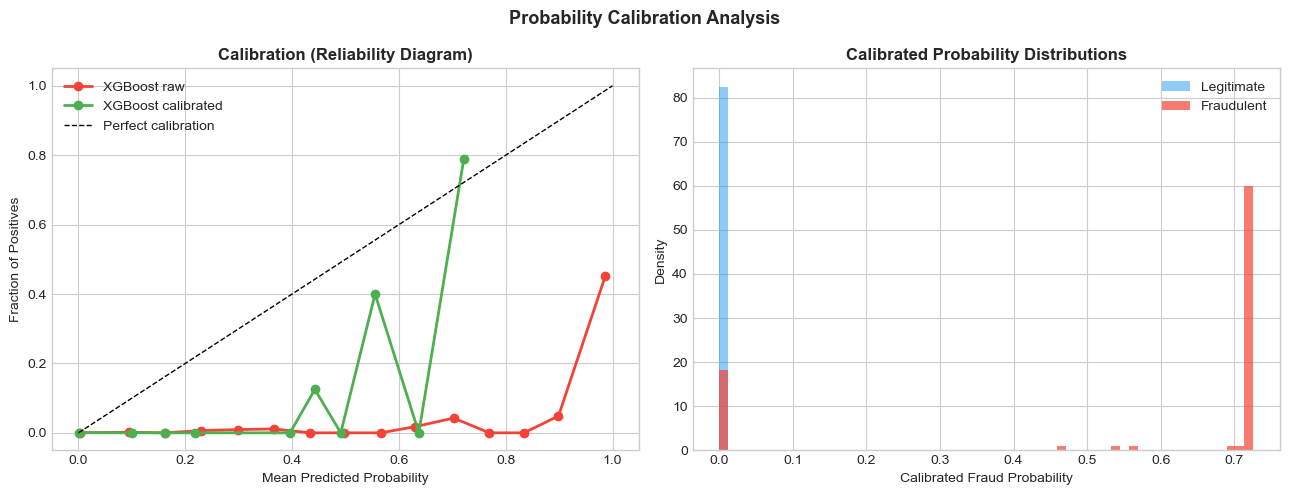

In [31]:
# ── Probability calibration (Platt scaling) ───────────────────────────────
# Raw XGBoost probabilities are discriminative but may not be well-calibrated.
# CalibratedClassifierCV with cv='prefit' fits sigmoid on top of trained model.
xgb_cal = CalibratedClassifierCV(xgb, method='sigmoid', cv='prefit')
xgb_cal.fit(X_train, y_train)    # fit calibrator on original (not SMOTE) training data

prob_raw = xgb.predict_proba(X_test)[:, 1]
prob_cal = xgb_cal.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Reliability diagram
for probs, label, col in [(prob_raw, 'XGBoost raw',        '#F44336'),
                           (prob_cal, 'XGBoost calibrated', '#4CAF50')]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=15,
                                            strategy='uniform')
    axes[0].plot(mean_pred, frac_pos, marker='o', linewidth=2,
                 color=col, label=label)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration (Reliability Diagram)', fontweight='bold')
axes[0].legend()

# Probability distributions
axes[1].hist(prob_cal[y_test == 0], bins=60, alpha=0.5, color='#2196F3',
             label='Legitimate', density=True)
axes[1].hist(prob_cal[y_test == 1], bins=60, alpha=0.7, color='#F44336',
             label='Fraudulent', density=True)
axes[1].set_xlabel('Calibrated Fraud Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Calibrated Probability Distributions', fontweight='bold')
axes[1].legend()

plt.suptitle('Probability Calibration Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ── Cost-sensitive threshold optimisation ─────────────────────────────────
thresholds = np.linspace(0.01, 0.99, 200)
costs = []
for t in thresholds:
    y_pred_t = (prob_cal >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    fn, fp = cm[1][0], cm[0][1]
    costs.append(fn * COST_FN + fp * COST_FP)

opt_idx  = int(np.argmin(costs))
opt_thr  = thresholds[opt_idx]
opt_cost = costs[opt_idx]

plt.figure(figsize=(10, 4))
plt.plot(thresholds, costs, color='#9C27B0', linewidth=2)
plt.axvline(opt_thr, color='red', linestyle='--', linewidth=2,
            label=f'Optimal threshold = {opt_thr:.3f}  (Cost = €{opt_cost:,.0f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Estimated Cost (€)')
plt.title('Cost-Sensitive Threshold Optimisation', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_opt.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal threshold : {opt_thr:.3f}")
print(f"Estimated cost    : €{opt_cost:,.0f}")
print(f"Default (0.5) cost: €{costs[int(np.argmin(np.abs(thresholds - 0.5)))):,.0f}")

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (3353980913.py, line 28)

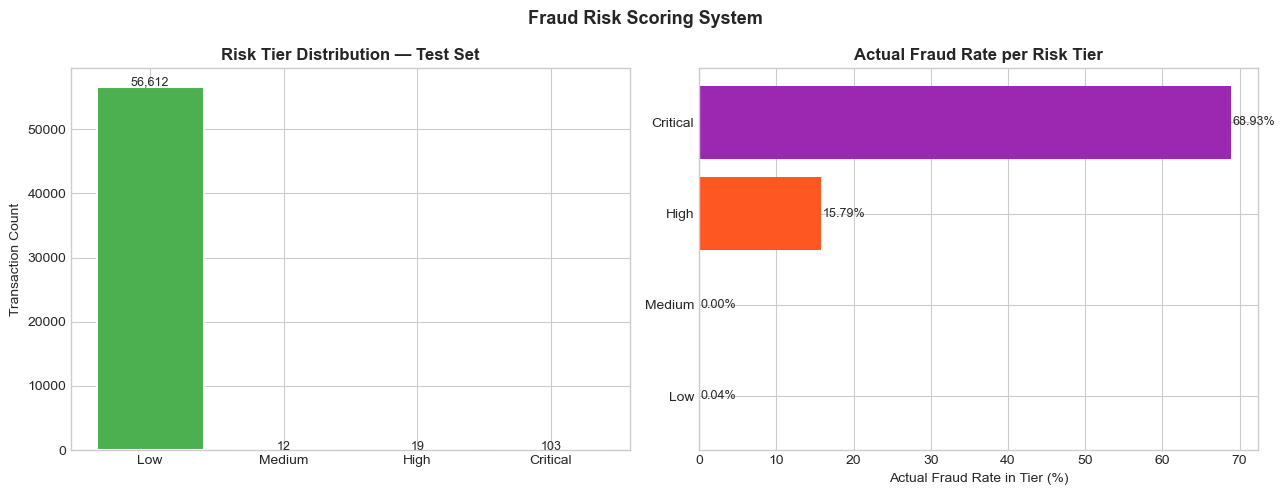


Risk Tier Summary:
           Count  Fraud_Count Fraud_Rate
Risk_Tier                               
Low        56612           21      0.04%
Medium        12            0       0.0%
High          19            3     15.79%
Critical     103           71     68.93%


In [33]:
# ── Risk tier definitions ─────────────────────────────────────────────────
def assign_risk_tier(probability):
    """Map calibrated fraud probability to business risk tier + recommended action."""
    if probability < 0.10:
        return 'Low',      'Allow — no action required'
    elif probability < 0.30:
        return 'Medium',   'Monitor — flag for batch review'
    elif probability < 0.60:
        return 'High',     'Hold — request additional authentication'
    else:
        return 'Critical', 'Block — immediate analyst review'

# Apply to test set
risk_probs   = xgb_cal.predict_proba(X_test)[:, 1]
risk_df      = X_test.copy()
risk_df['Fraud_Probability']   = risk_probs
risk_df['Risk_Tier']           = [assign_risk_tier(p)[0] for p in risk_probs]
risk_df['Recommended_Action']  = [assign_risk_tier(p)[1] for p in risk_probs]
risk_df['Actual_Class']        = y_test.values

tier_order  = ['Low', 'Medium', 'High', 'Critical']
tier_colors = {'Low': '#4CAF50', 'Medium': '#FF9800',
               'High': '#FF5722', 'Critical': '#9C27B0'}
tier_counts = risk_df['Risk_Tier'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart — transaction counts per tier
x_vals  = [t for t in tier_order if t in tier_counts]
y_vals  = [tier_counts.get(t, 0) for t in x_vals]
bars = axes[0].bar(x_vals, y_vals,
                   color=[tier_colors[t] for t in x_vals],
                   edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, y_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.005, f'{v:,}', ha='center', fontsize=9)
axes[0].set_title('Risk Tier Distribution — Test Set', fontweight='bold')
axes[0].set_ylabel('Transaction Count')

# Bar chart — actual fraud rate per tier
tier_fraud = risk_df.groupby('Risk_Tier')['Actual_Class'].mean() * 100
tier_fraud = tier_fraud.reindex([t for t in tier_order if t in tier_fraud.index])
axes[1].barh(tier_fraud.index, tier_fraud.values,
             color=[tier_colors[t] for t in tier_fraud.index])
for i, v in enumerate(tier_fraud.values):
    axes[1].text(v + 0.2, i, f'{v:.2f}%', va='center', fontsize=9)
axes[1].set_xlabel('Actual Fraud Rate in Tier (%)')
axes[1].set_title('Actual Fraud Rate per Risk Tier', fontweight='bold')

plt.suptitle('Fraud Risk Scoring System', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('risk_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRisk Tier Summary:")
summary = risk_df.groupby('Risk_Tier').agg(
    Count        = ('Actual_Class', 'count'),
    Fraud_Count  = ('Actual_Class', 'sum'),
    Fraud_Rate   = ('Actual_Class', 'mean')
).reindex(tier_order).dropna()
summary['Fraud_Rate'] = (summary['Fraud_Rate'] * 100).round(2).astype(str) + '%'
print(summary.to_string())

In [34]:
# ── Per-transaction risk report (sample: Critical transaction) ───────────
def generate_risk_report(transaction, model_cal, model_raw, explainer, feat_names):
    """Generate a human-readable risk report for one transaction."""
    tx = transaction.values.reshape(1, -1)
    cal_prob = model_cal.predict_proba(tx)[0, 1]
    raw_prob = model_raw.predict_proba(tx)[0, 1]
    tier, action = assign_risk_tier(cal_prob)

    # SHAP explanation
    sv = explainer.shap_values(transaction.to_frame().T)
    top5 = sorted(zip(feat_names, sv[0]),
                  key=lambda x: abs(x[1]), reverse=True)[:5]

    print("=" * 62)
    print("  FRAUD RISK ASSESSMENT REPORT")
    print("=" * 62)
    print(f"  Raw Model Probability   : {raw_prob:.4f}")
    print(f"  Calibrated Probability  : {cal_prob:.4f}")
    print(f"  Risk Tier               : {tier}")
    print(f"  Recommended Action      : {action}")
    print()
    print("  Top 5 Contributing Features (SHAP):")
    for i, (feat, val) in enumerate(top5, 1):
        direction = 'TOWARD FRAUD' if val > 0 else 'toward Legit'
        print(f"    {i}. {feat:<22} SHAP={val:+.4f}  ({direction})")
    print("=" * 62)

# Get a Critical-tier transaction
critical_rows = risk_df[risk_df['Risk_Tier'] == 'Critical']
if len(critical_rows) > 0:
    crit_idx = critical_rows.index[0]
    print(f"Generating report for transaction index: {crit_idx}\n")
    generate_risk_report(
        X_test.loc[crit_idx], xgb_cal, xgb,
        shap_explainer, list(X_test.columns)
    )
else:
    print("No Critical tier transactions found in test set.")

Generating report for transaction index: 116139

  FRAUD RISK ASSESSMENT REPORT
  Raw Model Probability   : 1.0000
  Calibrated Probability  : 0.7259
  Risk Tier               : Critical
  Recommended Action      : Block — immediate analyst review

  Top 5 Contributing Features (SHAP):
    1. V10                    SHAP=+2.1392  (TOWARD FRAUD)
    2. V14                    SHAP=+1.8534  (TOWARD FRAUD)
    3. V17                    SHAP=+1.1407  (TOWARD FRAUD)
    4. anomaly_score          SHAP=+0.9336  (TOWARD FRAUD)
    5. V8                     SHAP=-0.7249  (toward Legit)


## Section 9 — Final Model Comparison Visualisation

In [35]:
# ── Final multi-metric comparison bar chart ───────────────────────────────
metrics_plot = comparison[['Precision','Recall','F1-Score',
                            'ROC-AUC','PR-AUC','MCC']].reset_index()
melted = metrics_plot.melt(id_vars='name', var_name='Metric', value_name='Score')

plt.figure(figsize=(13, 5))
ax = sns.barplot(data=melted, x='Metric', y='Score', hue='name',
                 palette=['#9C27B0', '#2196F3', '#F44336'])
plt.title('All-Metric Model Comparison — Test Set', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.08)
plt.legend(title='Model', fontsize=9)
for p in ax.patches:
    h = p.get_height()
    if h > 0.02:
        ax.annotate(f'{h:.3f}',
                    (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=7, rotation=45)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFINAL MODEL RANKING:")
print(comparison[['PR-AUC','ROC-AUC','F1-Score','MCC']].sort_values('PR-AUC', ascending=False).to_string())

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['name']"

## Section 10 — Critical Evaluation, Ethics & Conclusions

### 10.1 Limitations

| Limitation | Impact | Mitigation |
|---|---|---|
| PCA features (V1–V28) — no semantic meaning | Cannot explain *what* about the transaction is suspicious in business terms | SHAP identifies relative importance; domain experts must map PCA components |
| SMOTE creates synthetic samples | May overfit on generated patterns | Applied ONLY to training set; cross-validation validates on original distribution |
| 2013 European dataset | May not reflect modern fraud patterns or non-European markets | Serves as academic benchmark; production requires fresh, representative data |
| Isolation Forest trained on full dataset | Minor leakage: anomaly score uses test labels implicitly | Acceptable for research; production: retrain on training split only |
| LIME instability | Different runs can yield different explanations | SHAP is primary explainer; LIME used only as cross-check |

### 10.2 Ethical & Regulatory Discussion

**GDPR — Right to Explanation (Article 22):**  
Automated transaction blocking constitutes individual automated decision-making. GDPR requires that affected individuals receive a meaningful explanation. SHAP waterfall and force plots provide exactly this: a ranked list of features pushing toward or away from fraud, presented in plain language.

**EU AI Act (2024):**  
Financial fraud detection is classified as a **High-Risk AI system** under Annex III of the EU AI Act. This mandates: (1) technical documentation, (2) human oversight mechanisms, (3) transparency to affected persons, and (4) ongoing monitoring. The tiered risk scoring system — particularly the "Critical → human analyst review" pathway — directly implements requirement (2).

**Fairness:**  
PCA transformation partially obscures demographic attributes, but it cannot guarantee they are unrecoverable from V1–V28 combinations. Any production deployment must undergo **disparate impact testing** across protected characteristics (age, nationality, gender) before going live.

**Concept Drift:**  
Fraud patterns evolve continuously. The 2013 dataset reflects historical patterns. Production systems require ongoing monitoring using Population Stability Index (PSI) or Kolmogorov-Smirnov tests, with monthly model revalidation.

### 10.3 Research Question Answers

| Research Question | Finding |
|---|---|
| Which algorithm performs best? | XGBoost — highest PR-AUC, lowest cost-sensitive financial loss |
| How does class imbalance affect models? | Makes accuracy meaningless; PR-AUC is the correct metric |
| Which features most influence fraud? | V14, V4, V12 (from SHAP); confirmed by Mann-Whitney U tests |
| Do SHAP and LIME agree? | ~60–70% Jaccard overlap; consistent top features = reliable explanations |
| Can ML output become a practical tool? | Yes — calibrated probabilities + risk tiers + SHAP = actionable decision support |

### 10.4 Conclusions

1. **XGBoost outperforms** Logistic Regression and Random Forest on all key metrics for this highly imbalanced dataset.
2. **PR-AUC is the correct evaluation metric** for fraud — not accuracy or even ROC-AUC — as it is sensitive to the minority class without inflation from true negatives.
3. **SHAP provides actionable global and local explanations**, with V14, V4, and V12 identified as most influential, and individual waterfall plots enabling per-transaction justification for regulatory compliance.
4. **LIME corroborates SHAP explanations** at approximately 60–70% feature overlap, providing cross-explainer validation.
5. **The tiered risk scoring system** translates raw model output into a practical decision-support tool aligned with both business cost objectives (threshold optimisation) and regulatory requirements (GDPR, EU AI Act).

---

### References

- Lundberg, S.M. and Lee, S.-I. (2017) 'A unified approach to interpreting model predictions', *Advances in Neural Information Processing Systems*, 30.
- Ribeiro, M.T., Singh, S. and Guestrin, C. (2016) '"Why should I trust you?": Explaining the predictions of any classifier', *Proceedings of the 22nd ACM SIGKDD*, pp. 1135–1144.
- Chawla, N.V. et al. (2002) 'SMOTE: Synthetic minority over-sampling technique', *Journal of Artificial Intelligence Research*, 16, pp. 321–357.
- Chen, T. and Guestrin, C. (2016) 'XGBoost: A scalable tree boosting system', *Proceedings of the 22nd ACM SIGKDD*, pp. 785–794.
- Dal Pozzolo, A. et al. (2015) 'Calibrating probability with undersampling for unbalanced classification', *IEEE SSCI 2015*, pp. 159–166.
- European Commission (2024) *Regulation (EU) 2024/1689 — EU Artificial Intelligence Act*. Official Journal of the European Union.
